# Casting Product Quality Inspection

## 01 - Dataset Exploration

Explore the casting product image dataset before model training.

### Goals
- Check dataset size
- Check class distribution
- Check image properties
- Visualize sample images
- Check corrupted images

In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [21]:
DATA_DIR = Path("../data/raw/casting_data/casting_data")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("Dataset:", DATA_DIR.resolve())

Dataset: D:\Casting Quality Inspection\data\raw\casting_data\casting_data


In [22]:
print("Train classes:", [x.name for x in TRAIN_DIR.iterdir()])
print("Test classes :", [x.name for x in TEST_DIR.iterdir()])

Train classes: ['def_front', 'ok_front']
Test classes : ['def_front', 'ok_front']


In [23]:
def count_images(folder):
    return len(list(folder.glob("*")))


for folder in [TRAIN_DIR, TEST_DIR]:
    print(f"\n{folder.name}")

    for class_dir in folder.iterdir():
        print(f"{class_dir.name}: {count_images(class_dir)}")


train
def_front: 3758
ok_front: 2875

test
def_front: 453
ok_front: 262


In [24]:
data = []

for split, folder in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    for class_dir in folder.iterdir():
        data.append({
            "split": split,
            "class": class_dir.name,
            "images": count_images(class_dir)
        })

df = pd.DataFrame(data)

df

,split,class,images
0,train,def_front,3758
1,train,ok_front,2875
2,test,def_front,453
3,test,ok_front,262


In [25]:
print("Total images:", df["images"].sum())

Total images: 7348


In [26]:
distribution = df.pivot(
    index="class",
    columns="split",
    values="images"
)

distribution

split,test,train
class,,
def_front,453,3758
ok_front,262,2875


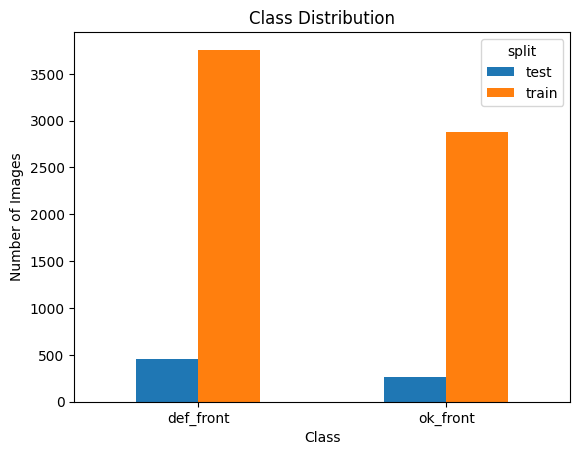

In [27]:
distribution.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.show()

In [28]:
train_data = df[df["split"] == "train"]

total = train_data["images"].sum()

for _, row in train_data.iterrows():
    percentage = row["images"] / total * 100
    print(f"{row['class']}: {percentage:.2f}%")

def_front: 56.66%
ok_front: 43.34%


In [29]:
image_files = list(TRAIN_DIR.rglob("*"))

image_files = [
    file for file in image_files
    if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

print("Images found:", len(image_files))

Images found: 6633


In [30]:
image = Image.open(image_files[0])

print("Size:", image.size)
print("Mode:", image.mode)

Size: (300, 300)
Mode: RGB


In [31]:
sizes = set()
modes = set()

for file in image_files:
    with Image.open(file) as image:
        sizes.add(image.size)
        modes.add(image.mode)

print("Image sizes:", sizes)
print("Image modes:", modes)

Image sizes: {(300, 300)}
Image modes: {'RGB'}


In [32]:
bad_images = []

for file in image_files:
    try:
        with Image.open(file) as image:
            image.verify()
    except:
        bad_images.append(file)

print("Corrupted images:", len(bad_images))

Corrupted images: 0


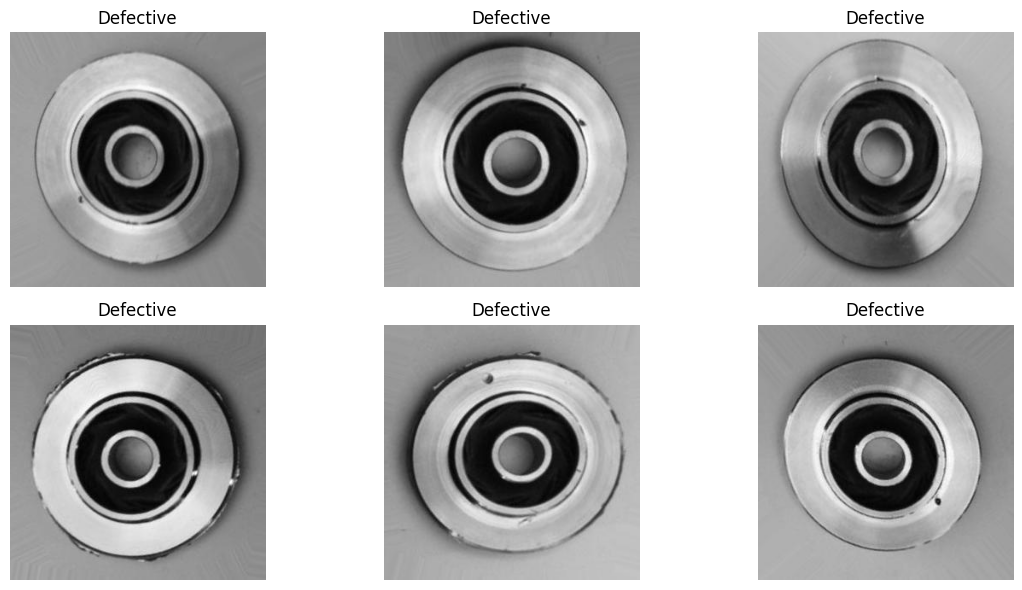

In [33]:
files = list((TRAIN_DIR / "def_front").glob("*"))[:6]

plt.figure(figsize=(12, 6))

for i, file in enumerate(files):
    image = Image.open(file)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Defective")
    plt.axis("off")

plt.tight_layout()
plt.show()

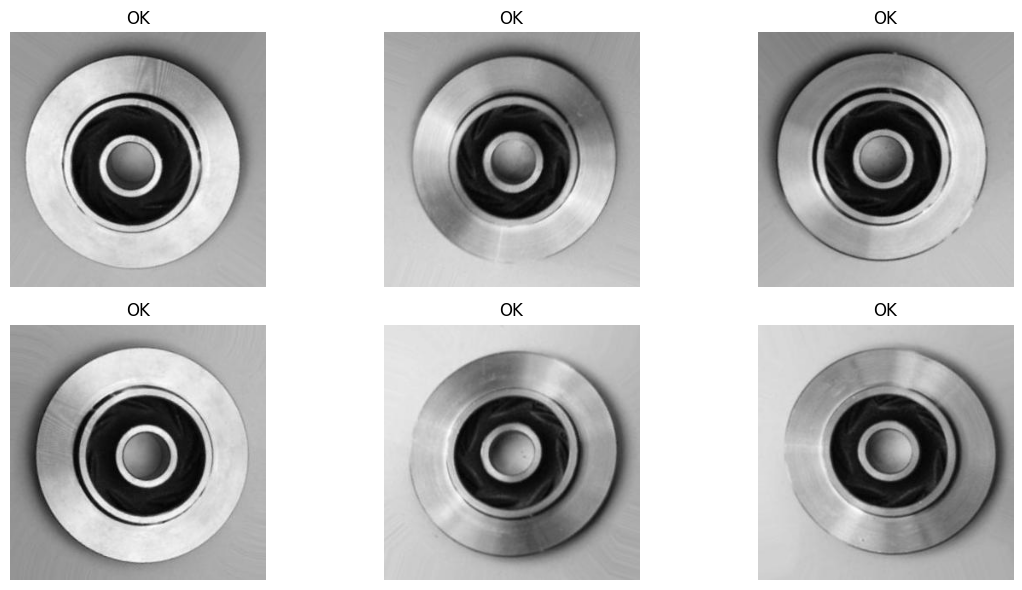

In [34]:
files = list((TRAIN_DIR / "ok_front").glob("*"))[:6]

plt.figure(figsize=(12, 6))

for i, file in enumerate(files):
    image = Image.open(file)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("OK")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Summary

The dataset contains casting product images for automated quality inspection.

### Dataset Overview

- **Total images:** 7,348
- **Training images:** 6,633
- **Test images:** 715
- **Classes:** 2
  - `def_front`: Defective products
  - `ok_front`: Acceptable products
- **Image size:** 300 × 300 pixels
- **Image format:** RGB

### Exploration

The dataset was explored to understand:

- Dataset structure and class distribution
- Number of images in each class
- Image dimensions and color channels
- Image consistency
- Potential corrupted images
- Visual differences between defective and acceptable products

The images have consistent dimensions and RGB color format, making the dataset suitable for image classification.

### Next Step

The next step is to prepare a consistent and leakage-aware data pipeline for model development.

The project will benchmark both **classical computer vision** and **deep learning** approaches.

#### Classical Computer Vision

Handcrafted features will be explored, including:

- HOG (Histogram of Oriented Gradients)
- LBP (Local Binary Patterns)
- Image histograms
- Edge-based features such as Sobel and Canny

These features will be evaluated with classical machine learning algorithms such as:

- SVM
- Random Forest

#### Deep Learning

Deep learning approaches will also be evaluated, including:

- Custom CNN
- Pretrained CNN architectures
- Transfer learning
- Fine-tuning

All approaches will use a consistent data split and evaluation protocol to ensure a fair comparison and minimize data leakage.

The goal is to identify the most suitable approach for automated casting defect classification and further optimize the best-performing model.